# 🔧 OnePilot — Forecasting | Notebook 8 : Fine-Tuning LSTM
**Objectif** : Optimiser les hyperparamètres LSTM sur SXA pour réduire le MAE  
**Méthode** : Grid search sur window, hidden_size, epochs, learning_rate  
**Baseline** : MAE 94,907 TND (Notebook 7)

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import itertools, time
import warnings; warnings.filterwarnings('ignore')

BASE_URL   = 'http://onepilot_api:8000'
SOURCE_SXA = '85a0ef4b-d9af-494f-b24f-ff710c21ba43'
device     = 'cuda' if torch.cuda.is_available() else 'cpu'

plt.rcParams.update({
    'figure.facecolor': '#060a0e', 'axes.facecolor': '#0d1520',
    'axes.edgecolor':   '#182336', 'text.color':     '#d8e8f2',
    'axes.labelcolor':  '#7ea4be', 'xtick.color':    '#7ea4be',
    'ytick.color':      '#7ea4be', 'grid.color':     '#182336',
    'grid.linestyle':   '--',      'grid.alpha':     0.5
})
print(f'✅ Imports OK | device={device}')

✅ Imports OK | device=cpu


In [2]:
# ── Chargement données SXA ────────────────────────────────────────
def run_sql(sql, source_id=SOURCE_SXA, limit=10000):
    resp = requests.post(f'{BASE_URL}/dashboard/data',
                         json={'sql': sql, 'source_id': source_id, 'limit': limit},
                         timeout=60)
    data = resp.json()
    if 'rows' not in data: raise Exception(data)
    return pd.DataFrame(data['rows'])

df_sxa = run_sql("""
    SELECT YEAR(TRNDATE) AS annee, DATEPART(WEEK, TRNDATE) AS semaine,
           MIN(TRNDATE) AS date_debut,
           SUM([montant avec signe]) AS flux_net
    FROM [Transactions bancaires]
    GROUP BY YEAR(TRNDATE), DATEPART(WEEK, TRNDATE)
    ORDER BY annee, semaine
""")
df_sxa['date']     = pd.to_datetime(df_sxa['date_debut'])
df_sxa             = df_sxa.set_index('date').sort_index()
df_sxa['flux_net'] = pd.to_numeric(df_sxa['flux_net'])
series             = df_sxa['flux_net']

split      = int(len(series) * 0.8)
train, test = series.iloc[:split], series.iloc[split:]

print(f'✅ Données SXA : {len(series)} semaines | train={len(train)} | test={len(test)}')
print(f'   Baseline MAE (NB7) : 94,907 TND  ← à battre')

✅ Données SXA : 78 semaines | train=62 | test=16
   Baseline MAE (NB7) : 94,907 TND  ← à battre


In [3]:
# ── Architecture LSTM ─────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, layers,
                            dropout=dropout if layers>1 else 0, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()


def train_and_eval(train_series, test_series, window, hidden, epochs, lr, batch=16):
    """Entraîne un LSTM et retourne le MAE sur le test."""
    scaler   = MinMaxScaler(feature_range=(-1, 1))
    train_sc = scaler.fit_transform(train_series.values.reshape(-1,1)).flatten()

    # Séquences
    X_lst, y_lst = [], []
    for i in range(len(train_sc)-window):
        X_lst.append(train_sc[i:i+window])
        y_lst.append(train_sc[i+window])
    if not X_lst: return float('inf')  # pas assez de données

    X_t = torch.FloatTensor(np.array(X_lst)).unsqueeze(-1).to(device)
    y_t = torch.FloatTensor(np.array(y_lst)).to(device)

    model  = LSTMForecaster(hidden=hidden).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    crit   = nn.MSELoss()
    loader = torch.utils.data.DataLoader(
                 torch.utils.data.TensorDataset(X_t, y_t), batch_size=batch, shuffle=True)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()

    # Prévision récursive
    model.eval()
    n_pred = len(test_series)
    win    = list(train_sc[-window:])
    preds  = []
    with torch.no_grad():
        for _ in range(n_pred):
            x_in = torch.FloatTensor(win[-window:]).unsqueeze(0).unsqueeze(-1).to(device)
            pred = model(x_in).item()
            preds.append(pred); win.append(pred)

    fc = scaler.inverse_transform(np.clip(preds, -1, 1).reshape(-1,1)).flatten()
    return mean_absolute_error(test_series.values, fc), model, scaler

print('✅ Fonctions définies')

✅ Fonctions définies


In [4]:
# ══════════════════════════════════════════════════════════════════
# GRID SEARCH — 4 hyperparamètres
# ══════════════════════════════════════════════════════════════════
GRID = {
    'window': [8, 12, 16],
    'hidden': [64, 128],
    'epochs': [150, 250],
    'lr':     [0.001, 0.0005]
}

combos  = list(itertools.product(*GRID.values()))
keys    = list(GRID.keys())
results = []

print(f'🔍 Grid Search — {len(combos)} combinaisons à tester\n')
t0 = time.time()

for idx, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    mae, _, _ = train_and_eval(train, test, **params)
    results.append({**params, 'mae': mae})
    elapsed = time.time() - t0
    print(f'  [{idx+1:2d}/{len(combos)}] window={params["window"]} hidden={params["hidden"]} '
          f'epochs={params["epochs"]} lr={params["lr"]} → MAE: {mae:,.0f} TND  ({elapsed:.0f}s)')

df_results = pd.DataFrame(results).sort_values('mae').reset_index(drop=True)
print(f'\n✅ Grid Search terminé en {time.time()-t0:.0f} secondes')

🔍 Grid Search — 24 combinaisons à tester

  [ 1/24] window=8 hidden=64 epochs=150 lr=0.001 → MAE: 98,594 TND  (2s)
  [ 2/24] window=8 hidden=64 epochs=150 lr=0.0005 → MAE: 96,515 TND  (3s)
  [ 3/24] window=8 hidden=64 epochs=250 lr=0.001 → MAE: 112,309 TND  (4s)
  [ 4/24] window=8 hidden=64 epochs=250 lr=0.0005 → MAE: 105,515 TND  (6s)
  [ 5/24] window=8 hidden=128 epochs=150 lr=0.001 → MAE: 161,970 TND  (8s)
  [ 6/24] window=8 hidden=128 epochs=150 lr=0.0005 → MAE: 94,356 TND  (9s)
  [ 7/24] window=8 hidden=128 epochs=250 lr=0.001 → MAE: 95,441 TND  (12s)
  [ 8/24] window=8 hidden=128 epochs=250 lr=0.0005 → MAE: 104,730 TND  (14s)
  [ 9/24] window=12 hidden=64 epochs=150 lr=0.001 → MAE: 104,424 TND  (15s)
  [10/24] window=12 hidden=64 epochs=150 lr=0.0005 → MAE: 112,271 TND  (18s)
  [11/24] window=12 hidden=64 epochs=250 lr=0.001 → MAE: 119,990 TND  (20s)
  [12/24] window=12 hidden=64 epochs=250 lr=0.0005 → MAE: 104,179 TND  (22s)
  [13/24] window=12 hidden=128 epochs=150 lr=0.001 → M

In [5]:
# ── Résultats du Grid Search ──────────────────────────────────────
print('='*65)
print('  CLASSEMENT GRID SEARCH (Top 5)')
print('='*65)
print(f"  {'#':<3} {'window':<8} {'hidden':<8} {'epochs':<8} {'lr':<8} {'MAE (TND)'}")
print('  ' + '-'*60)
for i, row in df_results.head(5).iterrows():
    badge = ' ✅ BEST' if i == 0 else ''
    print(f"  {i+1:<3} {int(row['window']):<8} {int(row['hidden']):<8} "
          f"{int(row['epochs']):<8} {row['lr']:<8} {row['mae']:,.0f}{badge}")

best_params = df_results.iloc[0][['window','hidden','epochs','lr']].to_dict()
best_params['window'] = int(best_params['window'])
best_params['hidden'] = int(best_params['hidden'])
best_params['epochs'] = int(best_params['epochs'])
best_mae_gs = df_results.iloc[0]['mae']

print(f'\n  Baseline NB7 : 94,907 TND')
print(f'  Meilleur GS  : {best_mae_gs:,.0f} TND')
gain = (94907 - best_mae_gs) / 94907 * 100
print(f'  Amélioration : {gain:.1f}%')

  CLASSEMENT GRID SEARCH (Top 5)
  #   window   hidden   epochs   lr       MAE (TND)
  ------------------------------------------------------------
  1   8        128      150      0.0005   94,356 ✅ BEST
  2   8        128      250      0.001    95,441
  3   8        64       150      0.0005   96,515
  4   8        64       150      0.001    98,594
  5   16       128      250      0.001    99,723

  Baseline NB7 : 94,907 TND
  Meilleur GS  : 94,356 TND
  Amélioration : 0.6%


In [6]:
# ── Réentraîner avec les meilleurs paramètres ─────────────────────
print(f'🏆 Réentraînement avec : {best_params}')
best_mae, best_model, best_scaler = train_and_eval(train, test, **best_params)
print(f'   MAE final : {best_mae:,.0f} TND')

# Prévisions finales
WINDOW   = best_params['window']
n_test   = len(test)
n_total  = n_test + 12

train_sc  = best_scaler.transform(train.values.reshape(-1,1)).flatten()
best_model.eval()
win = list(train_sc[-WINDOW:])
preds = []
with torch.no_grad():
    for _ in range(n_total):
        x_in = torch.FloatTensor(win[-WINDOW:]).unsqueeze(0).unsqueeze(-1).to(device)
        pred = best_model(x_in).item()
        preds.append(pred); win.append(pred)

fc_best = best_scaler.inverse_transform(np.clip(preds,-1,1).reshape(-1,1)).flatten()
future_idx = pd.date_range(start=train.index[-1]+pd.Timedelta(weeks=1), periods=n_total, freq='W')
print(f'✅ Prévisions {n_total} semaines générées')

🏆 Réentraînement avec : {'window': 8, 'hidden': 128, 'epochs': 150, 'lr': 0.0005}
   MAE final : 93,298 TND
✅ Prévisions 28 semaines générées


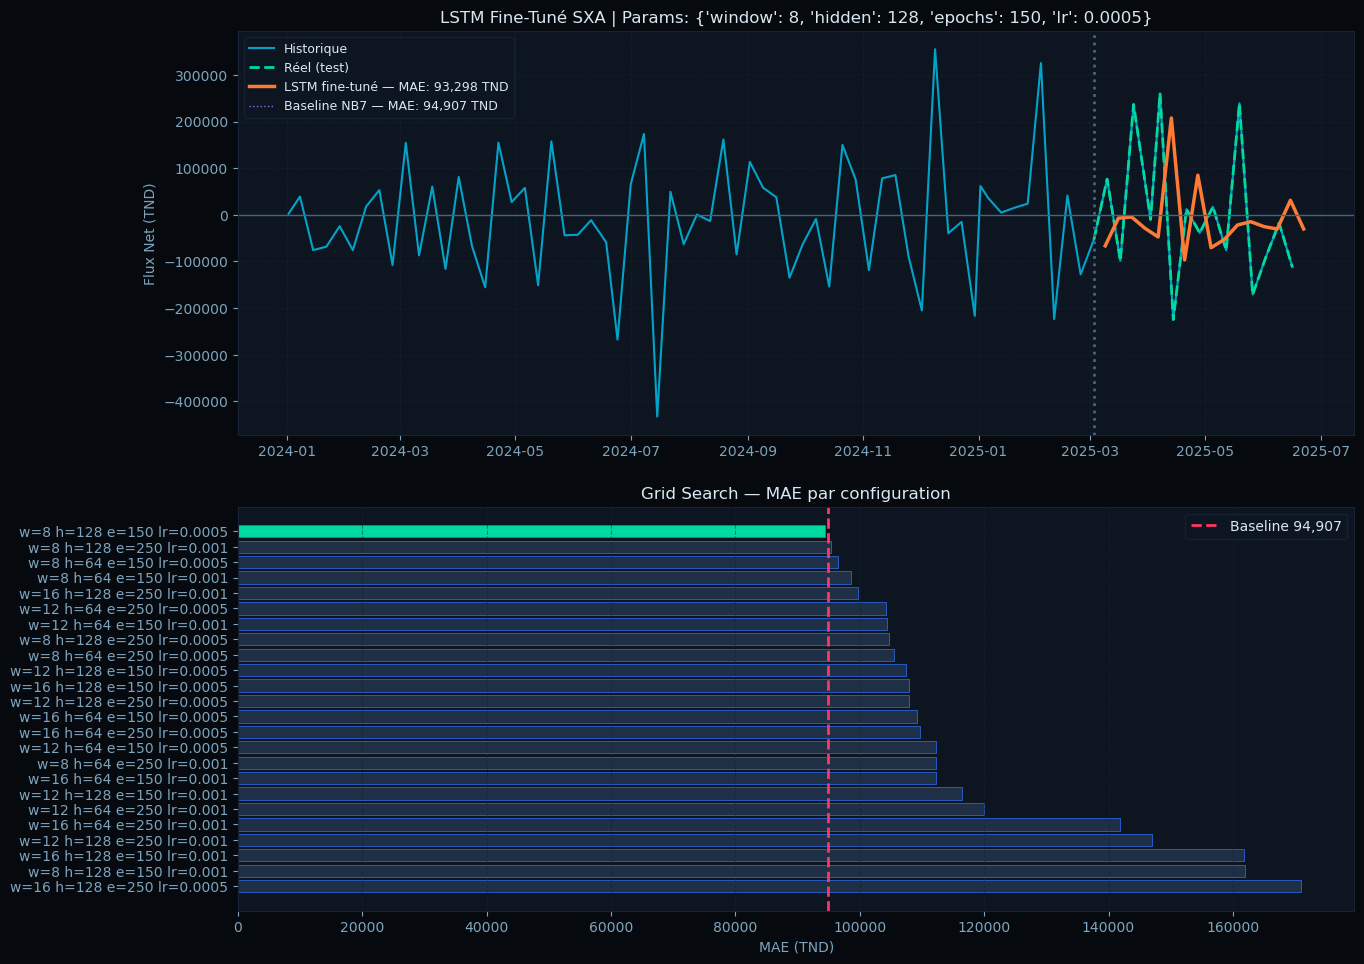

✅ Graphique sauvegardé → /tmp/finetune_results.png


In [7]:
# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 — Baseline vs Fine-tuné
ax1 = axes[0]
ax1.plot(series.index, series.values, color='#00c8f5', lw=1.5, label='Historique', alpha=0.8)
ax1.plot(test.index, test.values, color='#00d9a0', lw=2, linestyle='--', label='Réel (test)')
ax1.plot(future_idx[:n_test], fc_best[:n_test],
         color='#ff7a35', lw=2.5,
         label=f'LSTM fine-tuné — MAE: {best_mae:,.0f} TND')
ax1.plot(future_idx[:n_test],
         [None]*n_test,  # placeholder pour légende
         color='#8b6eff', lw=1, linestyle=':',
         label=f'Baseline NB7 — MAE: 94,907 TND')
ax1.axhline(0, color='#45657e', linestyle='-', lw=1)
ax1.axvline(x=test.index[0], color='#45657e', linestyle=':', lw=2)
ax1.set_title(f'LSTM Fine-Tuné SXA | Params: {best_params}', color='#d8e8f2', fontsize=12)
ax1.set_ylabel('Flux Net (TND)', color='#7ea4be')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2', fontsize=9)
ax1.grid(True)

# Graphique 2 — MAE par combinaison de paramètres
ax2 = axes[1]
labels = [f"w={int(r['window'])} h={int(r['hidden'])} e={int(r['epochs'])} lr={r['lr']}"
          for _, r in df_results.iterrows()]
colors = ['#00d9a0'] + ['#1f2f45'] * (len(df_results)-1)
bars = ax2.barh(labels, df_results['mae'], color=colors, edgecolor='#2d72ff', lw=0.5)
ax2.axvline(94907, color='#ff3663', linestyle='--', lw=2, label='Baseline 94,907')
ax2.set_title('Grid Search — MAE par configuration', color='#d8e8f2', fontsize=12)
ax2.set_xlabel('MAE (TND)', color='#7ea4be')
ax2.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax2.grid(True, axis='x')
ax2.invert_yaxis()

plt.tight_layout(pad=2)
plt.savefig('/tmp/finetune_results.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()
print('✅ Graphique sauvegardé → /tmp/finetune_results.png')

In [8]:
# ── Sauvegarder les meilleurs paramètres ─────────────────────────
import json
with open('/tmp/best_lstm_params.json', 'w') as f:
    json.dump({**best_params, 'mae': best_mae, 'source': 'SXA'}, f)

torch.save(best_model.state_dict(), '/tmp/lstm_sxa_finetuned.pt')

print('='*55)
print('  RÉSUMÉ FINE-TUNING LSTM — SXA')
print('='*55)
print(f'  Baseline NB7      : 94,907 TND')
print(f'  Meilleur GS       : {best_mae_gs:,.0f} TND')
print(f'  Réentraîné final  : {best_mae:,.0f} TND')
print(f'  Amélioration      : {gain:.1f}%')
print(f'  Meilleurs params  : {best_params}')
print()
print('  Fichiers sauvegardés :')
print('    /tmp/best_lstm_params.json  → paramètres optimaux')
print('    /tmp/lstm_sxa_finetuned.pt  → poids du modèle')
print()
print('  → Prochaine étape : forecast_agent.py')
print('    Intégration dans OnePilot avec les paramètres optimaux')

  RÉSUMÉ FINE-TUNING LSTM — SXA
  Baseline NB7      : 94,907 TND
  Meilleur GS       : 94,356 TND
  Réentraîné final  : 93,298 TND
  Amélioration      : 0.6%
  Meilleurs params  : {'window': 8, 'hidden': 128, 'epochs': 150, 'lr': 0.0005}

  Fichiers sauvegardés :
    /tmp/best_lstm_params.json  → paramètres optimaux
    /tmp/lstm_sxa_finetuned.pt  → poids du modèle

  → Prochaine étape : forecast_agent.py
    Intégration dans OnePilot avec les paramètres optimaux
